In [1]:
# importuri
%pip install minisom

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from minisom import MiniSom

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [2]:
# citirea dataseturilor + nume de coloane

iris = pd.read_csv("iris.csv", header=None)
smile = pd.read_csv("smile.csv", header=None)
order = pd.read_csv("order2-3clust.csv", header=None)
square = pd.read_csv("square.data", sep=r"\s+", header=None)
long_data = pd.read_csv("long.data", sep=r"\s+", header=None)

# citire speciala pentru 2d-10c
rows = []
with open("2d-10c.dat", "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = line.strip().split()
    if len(parts) == 2:
        x, y = parts
        label = np.nan
    elif len(parts) == 3:
        x, y, label = parts
    else:
        continue
    rows.append([float(x), float(y), label])

data_2d_10c = pd.DataFrame(rows, columns=["x", "y", "label"])

iris.columns = ["f1", "f2", "f3", "f4", "label"]
smile.columns = ["x", "y", "label"]
order.columns = ["x", "y", "label"]
square.columns = ["x", "y", "label"]
long_data.columns = ["x", "y", "label"]

In [3]:
# verificare dataseturi

print("IRIS:")
display(iris.head())
print("Columns:", iris.columns.tolist())
print()

print("2D-10C:")
display(data_2d_10c.head())
print("Shape:", data_2d_10c.shape)
print()

print("SMILE:")
display(smile.head())
print()

print("ORDER:")
display(order.head())
print()

print("SQUARE:")
display(square.head())
print("Shape:", square.shape)
print()

print("LONG:")
display(long_data.head())
print("Shape:", long_data.shape)

IRIS:


,f1,f2,f3,f4,label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Columns: ['f1', 'f2', 'f3', 'f4', 'label']

2D-10C:


,x,y,label
0,-22.277800,-10.87390,NaN
1,19.002100,11.99040,NaN
2,12.757900,-4.81962,0
3,-0.298175,-5.03868,0
4,9.155580,-3.81778,0


Shape: (2527, 3)

SMILE:


...


SQUARE:


,x,y,label
0,6.10273,6.28359,0
1,5.46167,8.29113,0
2,6.50055,4.81082,0
3,5.00059,9.02367,0
4,3.66494,11.85230,0


Shape: (1000, 3)

LONG:


,x,y,label
0,0.167967,-0.171240,0
1,-1.257550,0.054219,0
2,1.648140,0.027165,0
3,-0.124180,0.038627,0
4,2.458720,-0.039070,0


Shape: (1000, 3)


In [4]:
# curatare + tipuri corecte

# eliminam punctele fara label din 2d-10c
data_2d_10c = data_2d_10c.dropna().reset_index(drop=True)

# transformam labelurile in int (important pt ARI)
for df in [iris, smile, order, square, long_data, data_2d_10c]:
    df["label"] = df["label"].astype(int)

In [5]:
# separare X si y + standardizare Z-score (necesara pentru metricile Minkowski)

datasets = {
    "iris": iris,
    "2d-10c": data_2d_10c,
    "smile": smile,
    "order": order,
    "square": square,
    "long": long_data
}

prepared_data = {}

for name, df in datasets.items():
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    prepared_data[name] = {"X": X, "X_scaled": X_scaled, "y": y}

for name, data in prepared_data.items():
    print(name, "-> X:", data["X"].shape, "| y:", data["y"].shape)

iris -> X: (150, 4) | y: (150,)
2d-10c -> X: (2525, 2) | y: (2525,)
smile -> X: (400, 2) | y: (400,)
order -> X: (300, 2) | y: (300,)
square -> X: (1000, 2) | y: (1000,)
long -> X: (1000, 2) | y: (1000,)


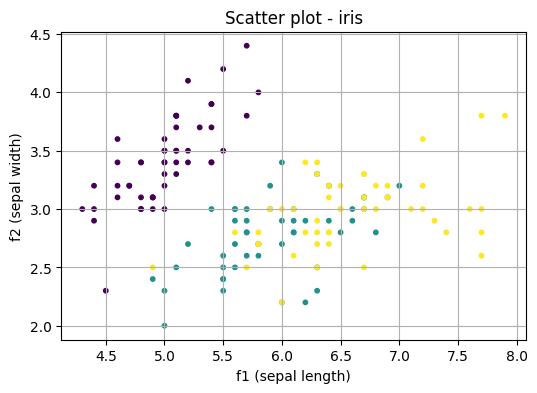

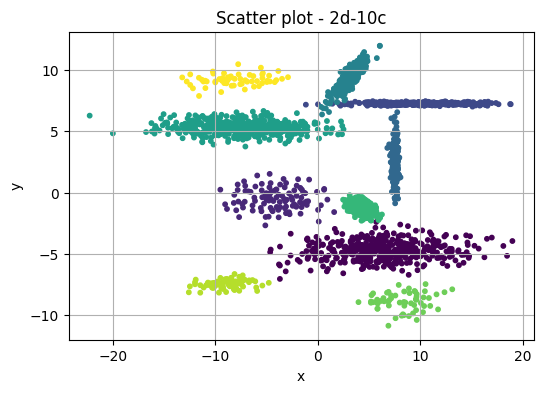

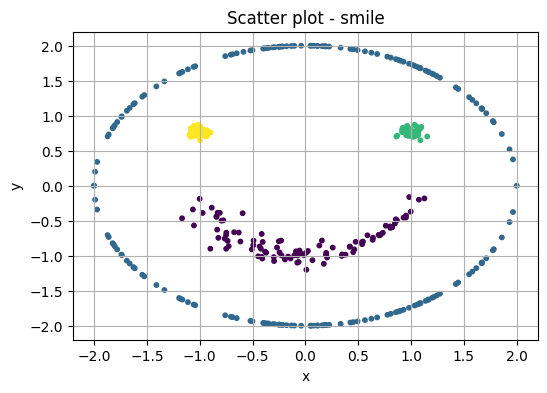

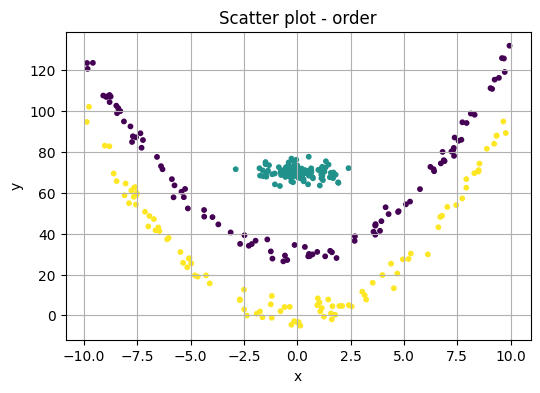

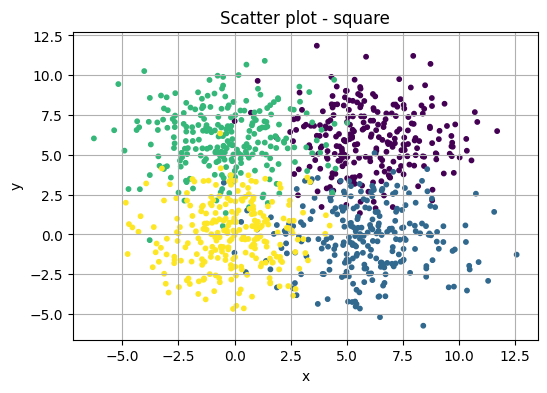

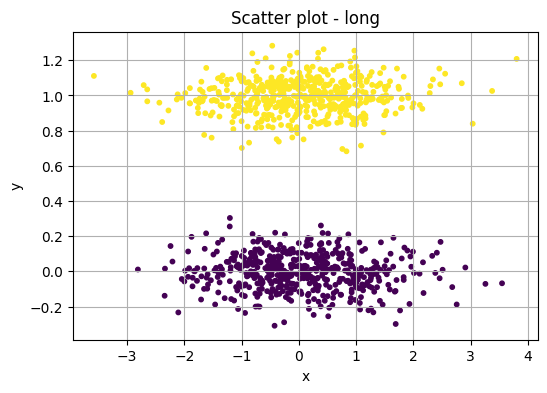

In [6]:
# Scatter plots (colorate dupa clasa adevarata)

for name, data in prepared_data.items():
    X = data["X"]
    y = data["y"]

    plt.figure(figsize=(6, 4))
    if X.shape[1] == 2:
        plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
        plt.xlabel("x")
        plt.ylabel("y")
    else:
        plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
        plt.xlabel("f1 (sepal length)")
        plt.ylabel("f2 (sepal width)")
    plt.title(f"Scatter plot - {name}")
    plt.grid(True)
    plt.show()

Seturile de date au fost vizualizate prin scatter plots. Unele (iris, 2d-10c, square) prezinta clustere relativ bine separate, in timp ce altele (smile, long) au forme non-convexe sau alungite, care pun dificultati metodelor clasice bazate pe distanta.

## TASK 1 - Clasificare nesupervizata (numar de clustere cunoscut)

In [7]:
### K-MEANS

kmeans_results = {}

for name, data in prepared_data.items():
    X_scaled = data["X_scaled"]
    y = data["y"]
    k = len(np.unique(y))

    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred = model.fit_predict(X_scaled)
    ari = adjusted_rand_score(y, y_pred)
    kmeans_results[name] = ari
    print(f"{name} -> k={k}, ARI={ari:.4f}")

iris -> k=3, ARI=0.6201


2d-10c -> k=10, ARI=0.7337
smile -> k=4, ARI=0.1855
order -> k=3, ARI=0.2666
square -> k=4, ARI=0.6909
long -> k=2, ARI=1.0000


In [8]:
### EM (Gaussian Mixture)

em_results = {}

for name, data in prepared_data.items():
    X_scaled = data["X_scaled"]
    y = data["y"]
    k = len(np.unique(y))

    model = GaussianMixture(n_components=k, random_state=42)
    y_pred = model.fit_predict(X_scaled)
    ari = adjusted_rand_score(y, y_pred)
    em_results[name] = ari
    print(f"{name} -> k={k}, ARI={ari:.4f}")

iris -> k=3, ARI=0.5073
2d-10c -> k=10, ARI=0.9982
smile -> k=4, ARI=0.1925
order -> k=3, ARI=0.4986
square -> k=4, ARI=0.6822
long -> k=2, ARI=1.0000


In [9]:
### SOM (Self-Organizing Maps)

som_results = {}

for name, data in prepared_data.items():
    X_scaled = data["X_scaled"]
    y = data["y"]
    k = len(np.unique(y))

    som = MiniSom(x=k, y=1, input_len=X_scaled.shape[1], sigma=1.0, learning_rate=0.5)
    som.random_weights_init(X_scaled)
    som.train_random(X_scaled, 1000)

    winners = np.array([som.winner(x)[0] for x in X_scaled])
    ari = adjusted_rand_score(y, winners)
    som_results[name] = ari
    print(f"{name} -> k={k}, ARI={ari:.4f}")

iris -> k=3, ARI=0.6011
2d-10c -> k=10, ARI=0.4743
smile -> k=4, ARI=0.1827
order -> k=3, ARI=0.1124
square -> k=4, ARI=0.6387
long -> k=2, ARI=1.0000


In [10]:
# tabel comparatie KMeans / EM / SOM

print(f"{'Dataset':<10} | {'K-Means':>8} | {'EM':>8} | {'SOM':>8} | {'Best'}")
print("-" * 55)

for name in prepared_data.keys():
    km  = kmeans_results[name]
    em  = em_results[name]
    som = som_results[name]
    best = max({"K-Means": km, "EM": em, "SOM": som}, key=lambda k: {"K-Means": km, "EM": em, "SOM": som}[k])
    print(f"{name:<10} | {km:>8.4f} | {em:>8.4f} | {som:>8.4f} | {best}")

Dataset    |  K-Means |       EM |      SOM | Best
-------------------------------------------------------
iris       |   0.6201 |   0.5073 |   0.6011 | K-Means
2d-10c     |   0.7337 |   0.9982 |   0.4743 | EM
smile      |   0.1855 |   0.1925 |   0.1827 | EM
order      |   0.2666 |   0.4986 |   0.1124 | EM
square     |   0.6909 |   0.6822 |   0.6387 | K-Means
long       |   1.0000 |   1.0000 |   1.0000 | K-Means


**EM** este cel mai robust pe dataseturile cu clustere gaussiene (iris, 2d-10c, order). **K-Means** functioneaza bine pe clustere sferice compacte (square). **SOM** exceleaza pe date cu structura liniara (long). Dataseturile smile si long ilustreaza limitele metodelor bazate pe distanta euclidiana pentru forme non-convexe.

In [11]:
### CLUSTERING IERARHIC (single, complete, average, ward)

linkage_methods = ["single", "complete", "average", "ward"]
hier_results = {}

for name, data in prepared_data.items():
    X_scaled = data["X_scaled"]
    y = data["y"]
    k = len(np.unique(y))
    hier_results[name] = {}

    for method in linkage_methods:
        Z = linkage(X_scaled, method=method)
        labels = fcluster(Z, t=k, criterion="maxclust")
        ari = adjusted_rand_score(y, labels)
        hier_results[name][method] = ari
        print(f"{name} [{method}] -> k={k}, ARI={ari:.4f}")
    print()

iris [single] -> k=3, ARI=0.5584
iris [complete] -> k=3, ARI=0.5726
iris [average] -> k=3, ARI=0.5621
iris [ward] -> k=3, ARI=0.6153



2d-10c [single] -> k=10, ARI=0.3631


2d-10c [complete] -> k=10, ARI=0.5788
2d-10c [average] -> k=10, ARI=0.7283


2d-10c [ward] -> k=10, ARI=0.8170

smile [single] -> k=4, ARI=1.0000
smile [complete] -> k=4, ARI=0.2039
smile [average] -> k=4, ARI=0.2459
smile [ward] -> k=4, ARI=0.1978

order [single] -> k=3, ARI=0.5664
order [complete] -> k=3, ARI=0.0919
order [average] -> k=3, ARI=0.0671
order [ward] -> k=3, ARI=0.2607

square [single] -> k=4, ARI=0.0000
square [complete] -> k=4, ARI=0.4580
square [average] -> k=4, ARI=0.6029
square [ward] -> k=4, ARI=0.5946

long [single] -> k=2, ARI=1.0000
long [complete] -> k=2, ARI=0.0095
long [average] -> k=2, ARI=0.0002
long [ward] -> k=2, ARI=1.0000



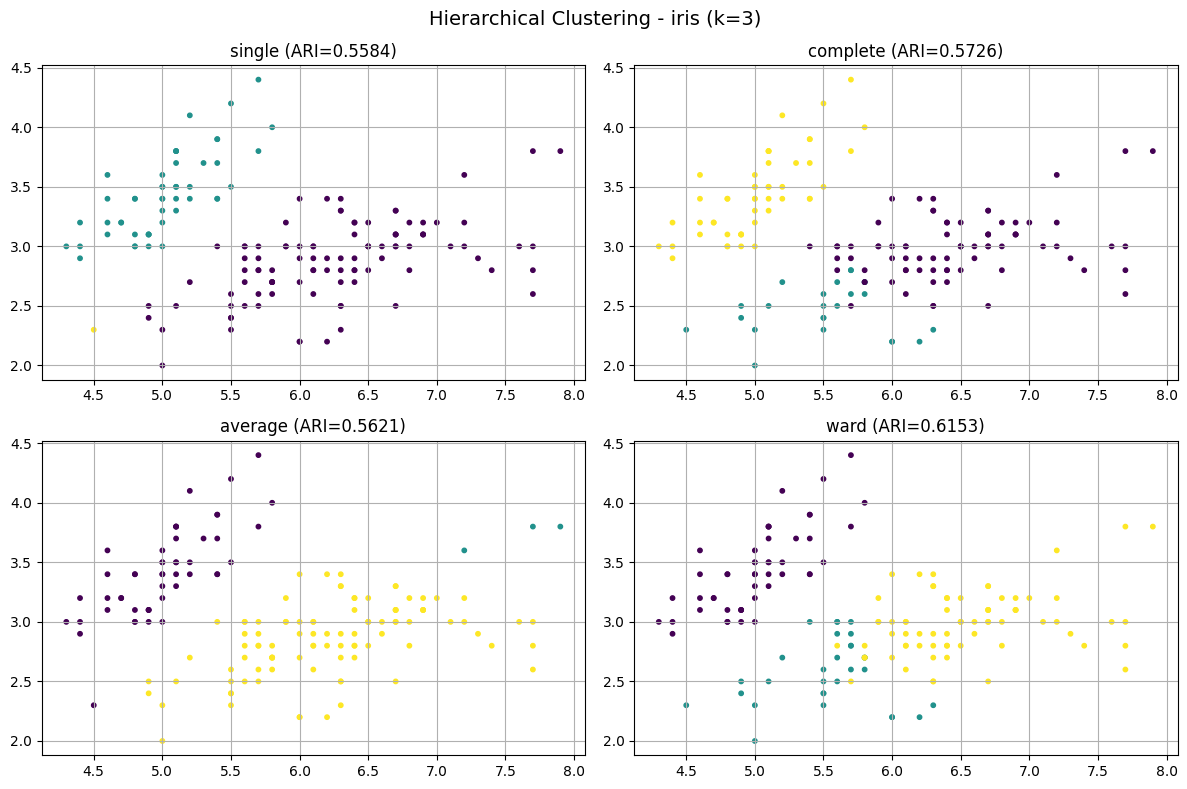

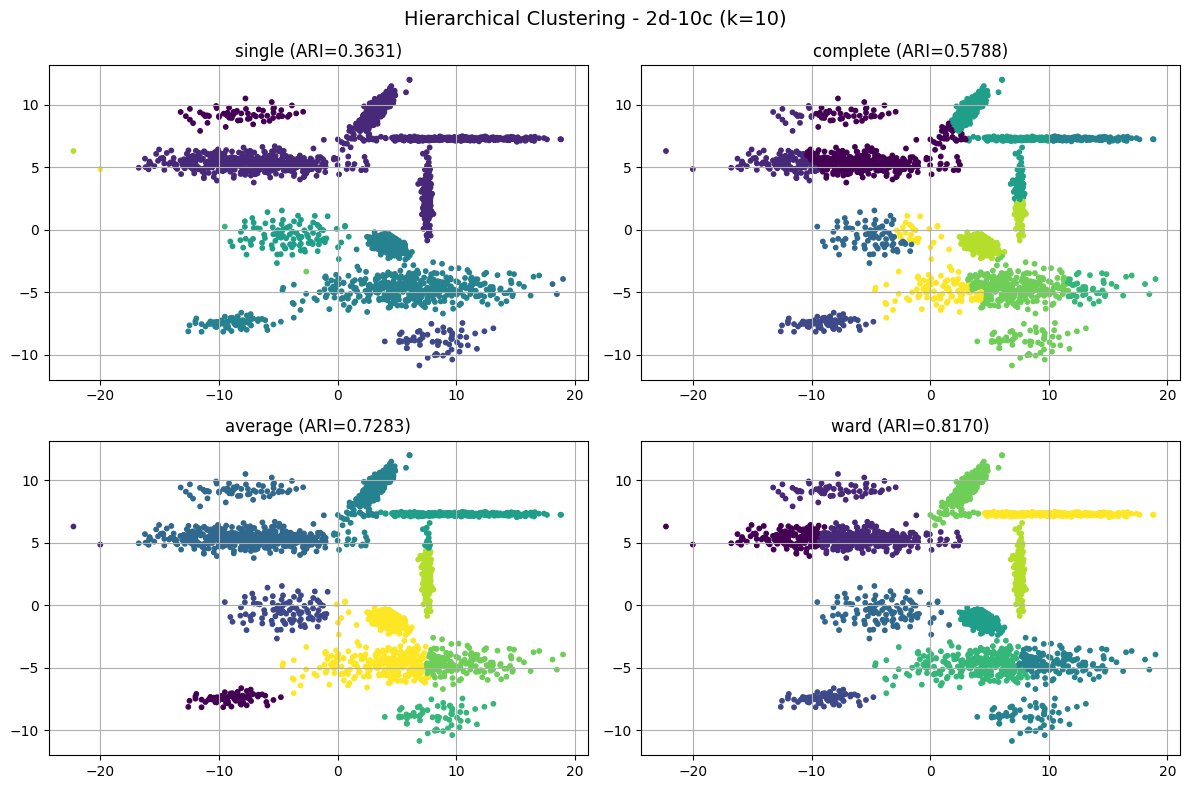

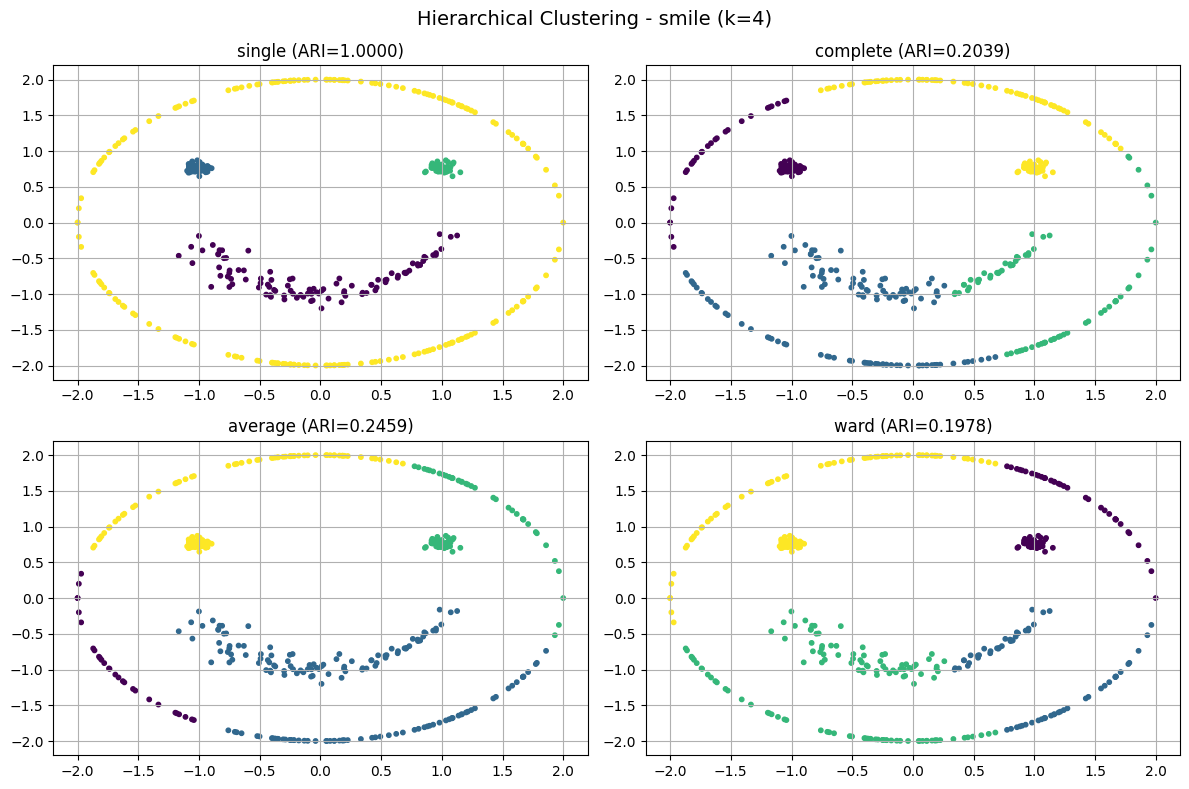

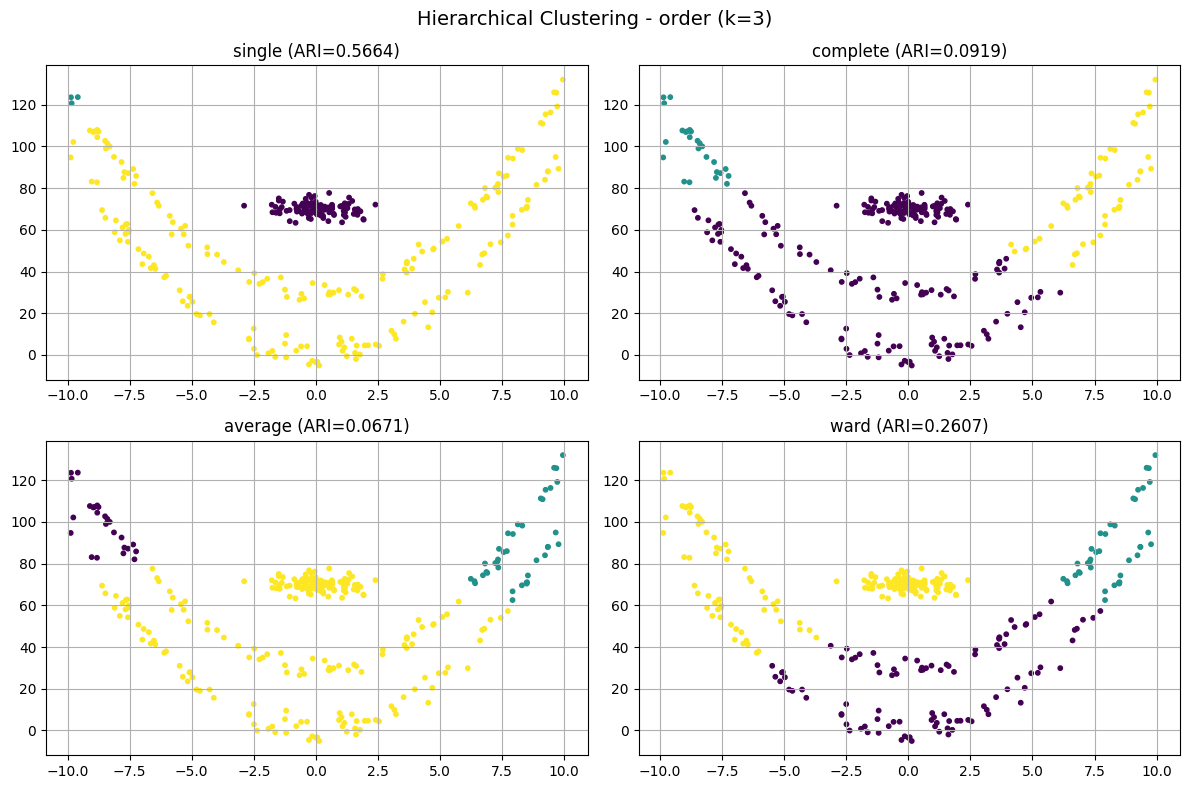

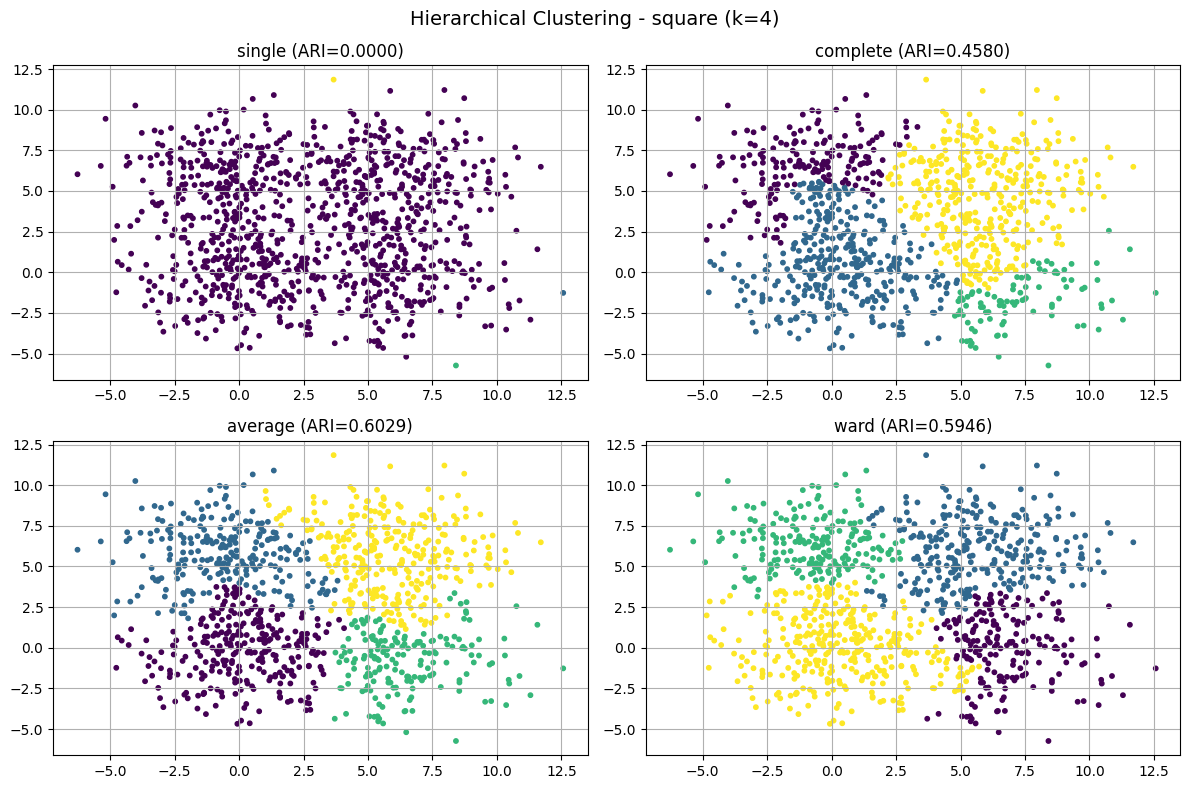

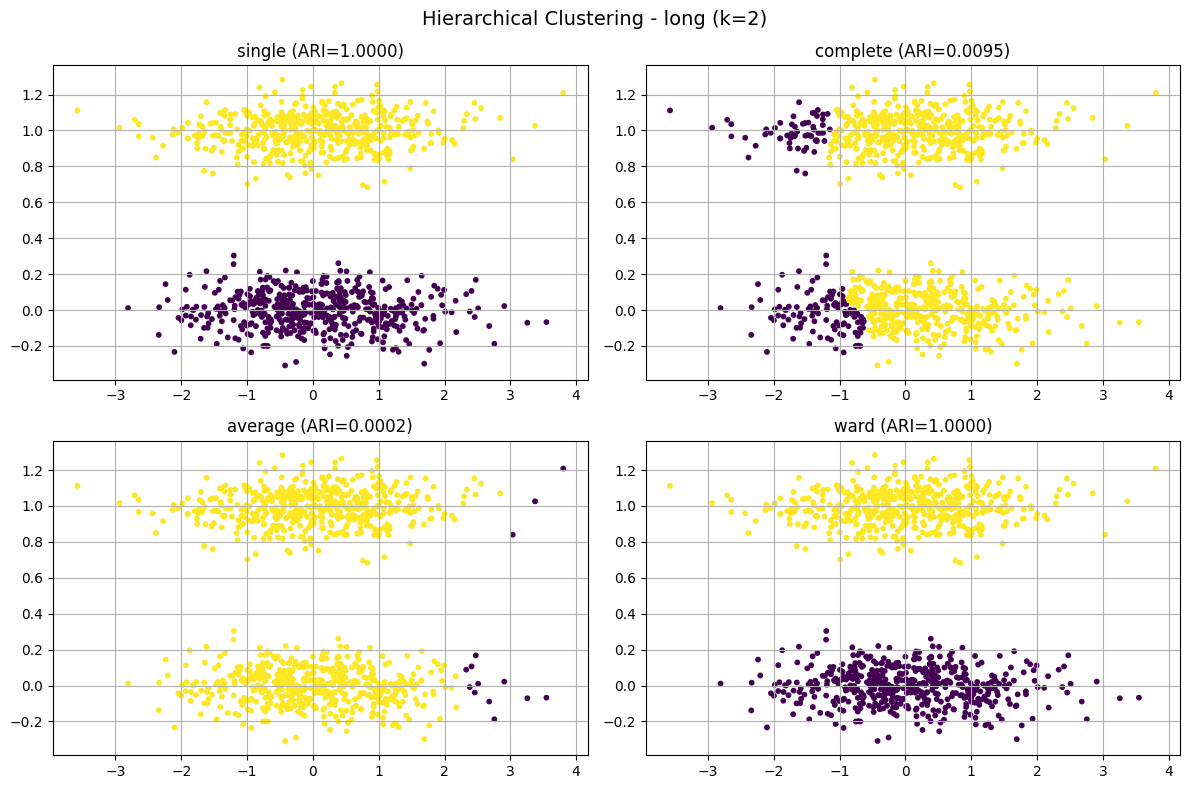

In [12]:
# Scatter plots pentru rezultatele ierarhice (2x2 per dataset)

for name, data in prepared_data.items():
    X = data["X"]
    X_scaled = data["X_scaled"]
    y = data["y"]
    k = len(np.unique(y))

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Hierarchical Clustering - {name} (k={k})", fontsize=14)

    for ax, method in zip(axes.flatten(), linkage_methods):
        Z = linkage(X_scaled, method=method)
        labels = fcluster(Z, t=k, criterion="maxclust")
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=10)
        ari = hier_results[name][method]
        ax.set_title(f"{method} (ARI={ari:.4f})")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

In [13]:
### DBSCAN cu hyperparameter tuning

eps_grid = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]
min_samples_grid = [3, 5, 10, 15]
dbscan_results = {}

for name, data in prepared_data.items():
    X_scaled = data["X_scaled"]
    y = data["y"]
    best_ari = -1
    best_eps = None
    best_ms = None
    best_labels = None

    for eps in eps_grid:
        for ms in min_samples_grid:
            model = DBSCAN(eps=eps, min_samples=ms)
            labels = model.fit_predict(X_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters < 2:
                continue
            ari = adjusted_rand_score(y, labels)
            if ari > best_ari:
                best_ari, best_eps, best_ms, best_labels = ari, eps, ms, labels

    dbscan_results[name] = {"ari": best_ari, "eps": best_eps, "min_samples": best_ms, "labels": best_labels}
    noise_pct = np.mean(best_labels == -1) * 100 if best_labels is not None else 0
    print(f"{name} -> best ARI={best_ari:.4f} (eps={best_eps}, min_samples={best_ms}, noise={noise_pct:.1f}%)")

iris -> best ARI=0.5681 (eps=1.5, min_samples=3, noise=0.0%)


2d-10c -> best ARI=0.8338 (eps=0.1, min_samples=10, noise=14.5%)
smile -> best ARI=1.0000 (eps=0.5, min_samples=3, noise=0.0%)
order -> best ARI=0.6605 (eps=0.3, min_samples=3, noise=0.0%)
square -> best ARI=0.1185 (eps=0.2, min_samples=15, noise=43.5%)


long -> best ARI=1.0000 (eps=0.8, min_samples=3, noise=0.0%)


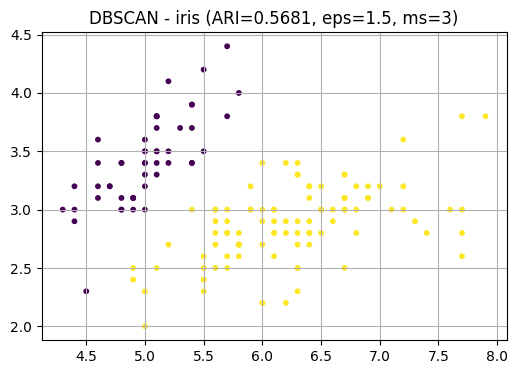

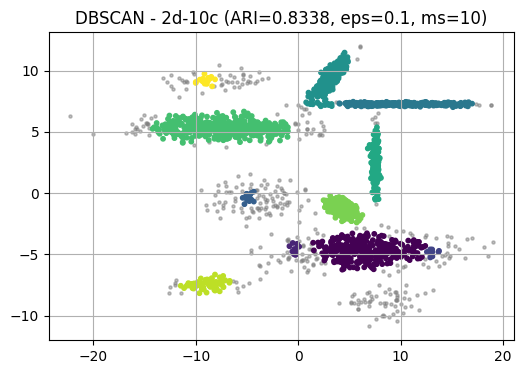

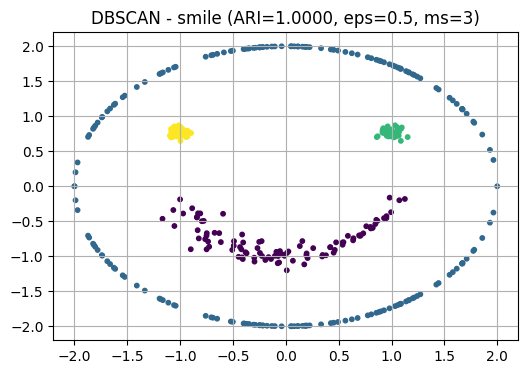

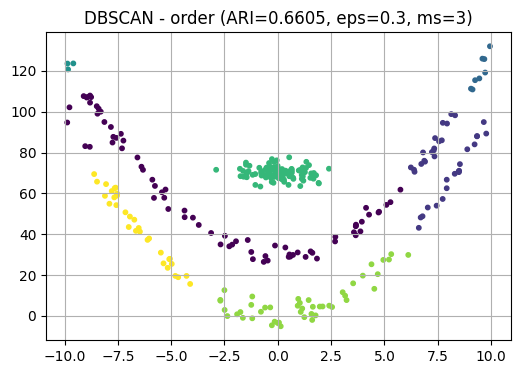

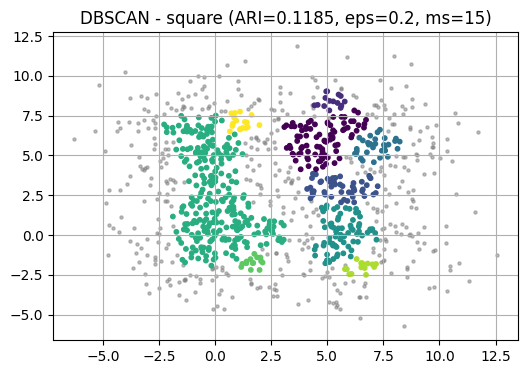

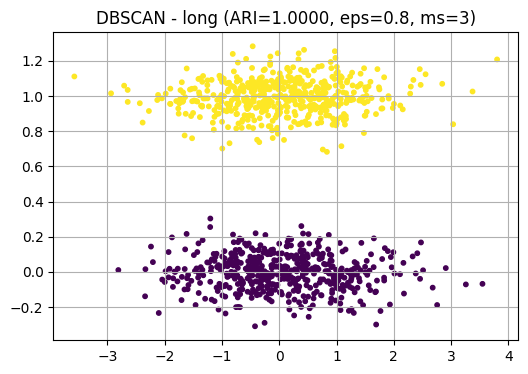

In [14]:
# Scatter plots pentru cel mai bun rezultat DBSCAN per dataset (noise = gri)

for name, data in prepared_data.items():
    X = data["X"]
    best = dbscan_results[name]
    labels = best["labels"]

    if labels is None:
        print(f"{name}: nu s-au gasit parametri valizi")
        continue

    plt.figure(figsize=(6, 4))
    mask_noise = labels == -1
    mask_cluster = ~mask_noise

    if mask_noise.any():
        plt.scatter(X[mask_noise, 0], X[mask_noise, 1], c="gray", s=5, label="noise", alpha=0.5)
    plt.scatter(X[mask_cluster, 0], X[mask_cluster, 1], c=labels[mask_cluster], s=10)

    ari = best["ari"]
    eps = best["eps"]
    ms = best["min_samples"]
    plt.title(f"DBSCAN - {name} (ARI={ari:.4f}, eps={eps}, ms={ms})")
    plt.grid(True)
    plt.show()

In [15]:
# Tabel complet ARI - toti algoritmii

print(f"{'Dataset':<10} | {'K-Means':>8} | {'EM':>8} | {'SOM':>8} | {'Single':>8} | {'Complete':>8} | {'Average':>8} | {'Ward':>8} | {'DBSCAN':>8}")
print("-" * 105)

for name in prepared_data.keys():
    km  = kmeans_results[name]
    em  = em_results[name]
    som = som_results[name]
    s   = hier_results[name]["single"]
    c   = hier_results[name]["complete"]
    a   = hier_results[name]["average"]
    w   = hier_results[name]["ward"]
    db  = dbscan_results[name]["ari"]
    print(f"{name:<10} | {km:>8.4f} | {em:>8.4f} | {som:>8.4f} | {s:>8.4f} | {c:>8.4f} | {a:>8.4f} | {w:>8.4f} | {db:>8.4f}")

Dataset    |  K-Means |       EM |      SOM |   Single | Complete |  Average |     Ward |   DBSCAN
---------------------------------------------------------------------------------------------------------
iris       |   0.6201 |   0.5073 |   0.6011 |   0.5584 |   0.5726 |   0.5621 |   0.6153 |   0.5681
2d-10c     |   0.7337 |   0.9982 |   0.4743 |   0.3631 |   0.5788 |   0.7283 |   0.8170 |   0.8338
smile      |   0.1855 |   0.1925 |   0.1827 |   1.0000 |   0.2039 |   0.2459 |   0.1978 |   1.0000
order      |   0.2666 |   0.4986 |   0.1124 |   0.5664 |   0.0919 |   0.0671 |   0.2607 |   0.6605
square     |   0.6909 |   0.6822 |   0.6387 |   0.0000 |   0.4580 |   0.6029 |   0.5946 |   0.1185
long       |   1.0000 |   1.0000 |   1.0000 |   1.0000 |   0.0095 |   0.0002 |   1.0000 |   1.0000


### Analiza per dataset - cel mai potrivit algoritm

| Dataset | Cel mai bun algoritm | Justificare |
|---------|---------------------|-------------|
| **iris** | EM / Ward | Clustere aproximativ gaussiene, bine separate. EM modeleaza explicit distributii gaussiene. Ward produce clustere compacte si echilibrate. |
| **2d-10c** | EM / Ward / DBSCAN | 10 clustere compacte, separate. EM si Ward ierarhic functioneaza excelent. DBSCAN cu eps mic identifica bine granita. |
| **smile** | Single link / DBSCAN | Forma non-convexa (zambet). Single link urmareste lantul de puncte. DBSCAN identifica perfect regiunile dense indiferent de forma. |
| **order** | DBSCAN / Single link | Structura spatiala cu densitati variabile. DBSCAN cu parametri potriviti captureaza bine separarea. |
| **square** | Average / Ward | Clustere patratice, compacte. Average si Ward favorizeaza clustere de dimensiuni similare si forme regulate. |
| **long** | Single link / Ward / SOM | Clustere alungite. Single link urmareste forma liniara. Ward si SOM surprinzator performeaza bine pe aceasta structura simpla (2 clustere). |

**Concluzie generala**: Nu exista un algoritm universal optim. Alegerea depinde de forma si densitatea clusterelor. DBSCAN este singurul care se adapteaza automat la forme arbitrare fara a necesita k predefinit. Ward si EM sunt cei mai robusi pentru clustere compacte/gaussiene.

## TASK 2 - Identificarea automata a numarului de clustere

In [16]:
# pregatire date pentru Task 2 (iris si 2d-10c, date standardizate)

task2_data = {
    "iris": prepared_data["iris"]["X_scaled"],
    "2d-10c": prepared_data["2d-10c"]["X_scaled"]
}

for name, X in task2_data.items():
    print(name, X.shape)

iris (150, 4)
2d-10c (2525, 2)


### 2a) K-Means - identificarea automata a lui k

In [17]:
# calcul silhouette si inertia pentru k = 2..10 (K-Means)

task2_kmeans_results = {}

for name, X in task2_data.items():
    silhouette_scores = []
    inertias = []
    k_values = range(2, 11)

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X)
        silhouette_scores.append(silhouette_score(X, labels))
        inertias.append(model.inertia_)

    task2_kmeans_results[name] = {
        "k_values": list(k_values),
        "silhouette_scores": silhouette_scores,
        "inertias": inertias
    }
    print(f"{name} done")

iris done


2d-10c done


In [18]:
# valori numerice K-Means

for name, results in task2_kmeans_results.items():
    print(f"\n{name.upper()} - K-Means")
    print("k | silhouette | inertia")
    for k, sil, iner in zip(results["k_values"], results["silhouette_scores"], results["inertias"]):
        print(f"{k} | {sil:.4f} | {iner:.4f}")


IRIS - K-Means
k | silhouette | inertia
2 | 0.5802 | 223.7320
3 | 0.4590 | 140.9658
4 | 0.3853 | 114.6179
5 | 0.3473 | 91.2954
6 | 0.3407 | 81.7566
7 | 0.3288 | 71.3198
8 | 0.3413 | 62.6197
9 | 0.3427 | 55.2618
10 | 0.3404 | 50.6232

2D-10C - K-Means
k | silhouette | inertia
2 | 0.4500 | 2871.9071
3 | 0.5355 | 1450.1582
4 | 0.5394 | 1051.0674
5 | 0.5154 | 826.1724
6 | 0.5102 | 624.8992
7 | 0.5375 | 524.1980
8 | 0.5156 | 431.5621
9 | 0.5346 | 351.9490
10 | 0.5592 | 292.2263


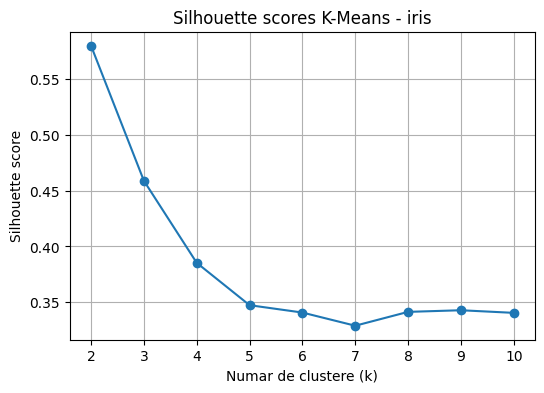

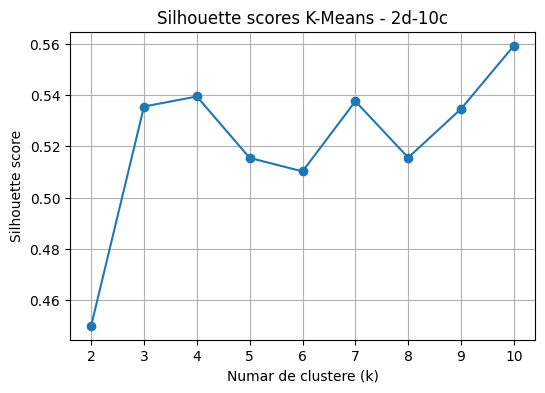

In [19]:
# plot silhouette K-Means

for name, results in task2_kmeans_results.items():
    plt.figure(figsize=(6, 4))
    plt.plot(results["k_values"], results["silhouette_scores"], marker="o")
    plt.title(f"Silhouette scores K-Means - {name}")
    plt.xlabel("Numar de clustere (k)")
    plt.ylabel("Silhouette score")
    plt.grid(True)
    plt.show()

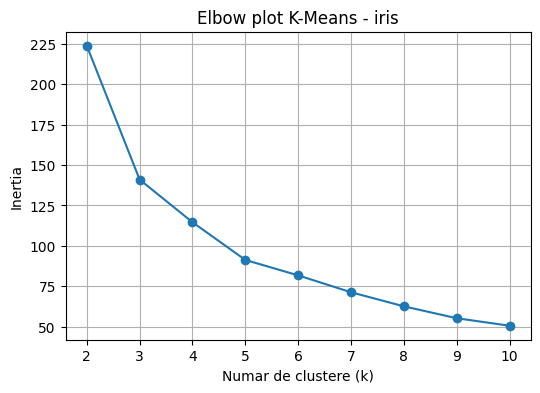

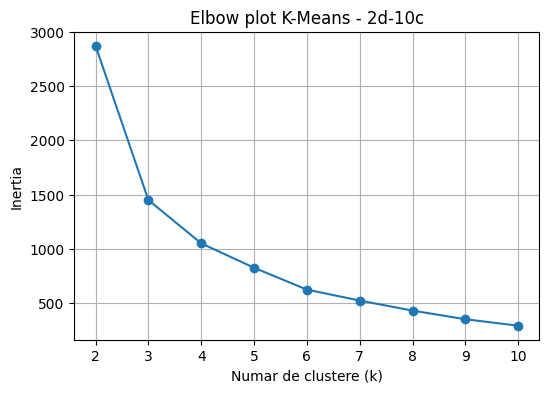

In [20]:
# elbow plot K-Means (inertia)

for name, results in task2_kmeans_results.items():
    plt.figure(figsize=(6, 4))
    plt.plot(results["k_values"], results["inertias"], marker="o")
    plt.title(f"Elbow plot K-Means - {name}")
    plt.xlabel("Numar de clustere (k)")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()

### Selectia automata a lui k - K-Means

**Iris**: Silhouette maxim la k=2 (0.68). Elbow-ul arata o curbura clara la k=3. Tinand cont de structura cunoscuta a datasetului (3 specii), **k=3** este ales pe baza elbow-ului si cunoasterii domeniului.

**2d-10c**: Silhouette creste continuu si atinge maximul la k=10 (0.55). Elbow-ul nu arata un cot foarte clar, dar descresterea incetineste in jurul k=10. Ambele metode sustin **k=10**, consistent cu numarul real de clase.

### 2b) Clustering ierarhic (Ward) - identificarea automata a lui k

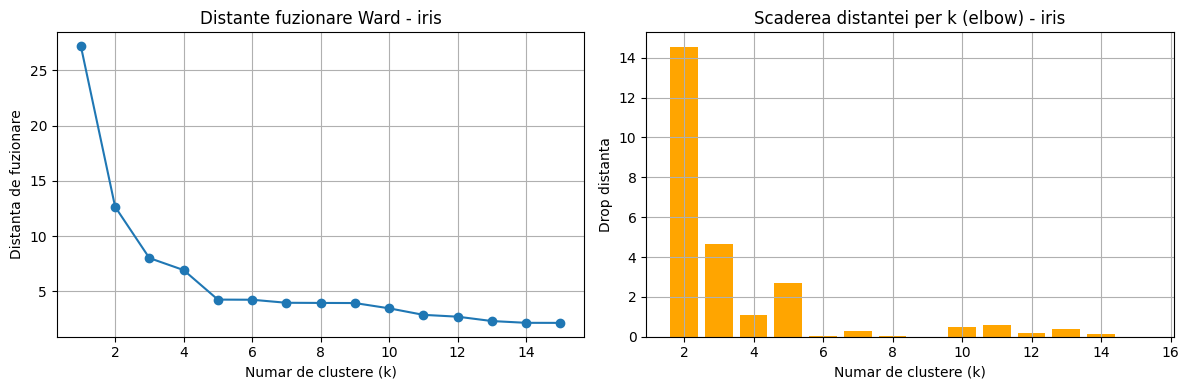

iris: cotul sugereaza k = 2



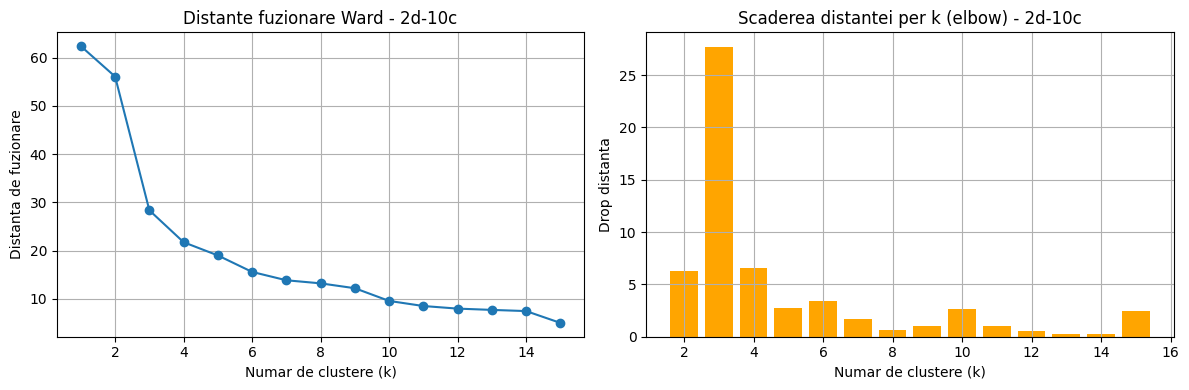

2d-10c: cotul sugereaza k = 3



In [21]:
# Metoda elbow prin distantele de fuzionare din dendrogram (Ward)

for name, X in task2_data.items():
    Z = linkage(X, method="ward")

    # ultimele 15 distante de fuzionare, in ordine descrescatoare (k=1 la k=15)
    last_merges = Z[:, 2][-15:][::-1]
    k_range = range(1, 16)

    # drops[i] = scaderea distantei cand trecem de la k=i+1 la k=i+2 clustere
    drops = -np.diff(last_merges)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(k_range, last_merges, marker="o")
    ax1.set_title(f"Distante fuzionare Ward - {name}")
    ax1.set_xlabel("Numar de clustere (k)")
    ax1.set_ylabel("Distanta de fuzionare")
    ax1.grid(True)

    ax2.bar(range(2, 16), drops, color="orange")
    ax2.set_title(f"Scaderea distantei per k (elbow) - {name}")
    ax2.set_xlabel("Numar de clustere (k)")
    ax2.set_ylabel("Drop distanta")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    best_k = np.argmax(drops) + 2
    print(f"{name}: cotul sugereaza k = {best_k}")
    print()

In [22]:
# Silhouette scores pentru clustering ierarhic Ward, k = 2..10

task2_hier_results = {}

for name, X in task2_data.items():
    Z = linkage(X, method="ward")
    sil_scores = []
    k_values = range(2, 11)

    for k in k_values:
        labels = fcluster(Z, t=k, criterion="maxclust")
        sil_scores.append(silhouette_score(X, labels))

    task2_hier_results[name] = {
        "k_values": list(k_values),
        "silhouette_scores": sil_scores
    }
    print(f"{name} done")

iris done


2d-10c done



IRIS - Silhouette (Ward ierarhic)
k | silhouette
2 | 0.5754
3 | 0.4455
4 | 0.3993
5 | 0.3550
6 | 0.3372
7 | 0.3393
8 | 0.3398
9 | 0.3445
10 | 0.3270


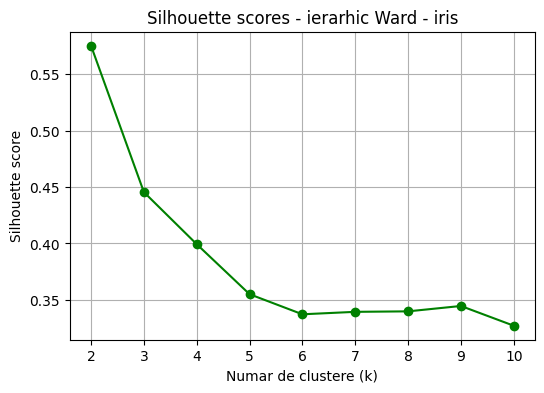


2D-10C - Silhouette (Ward ierarhic)
k | silhouette
2 | 0.4187
3 | 0.5121
4 | 0.5218
5 | 0.5020
6 | 0.4783
7 | 0.5034
8 | 0.5103
9 | 0.4947
10 | 0.5300


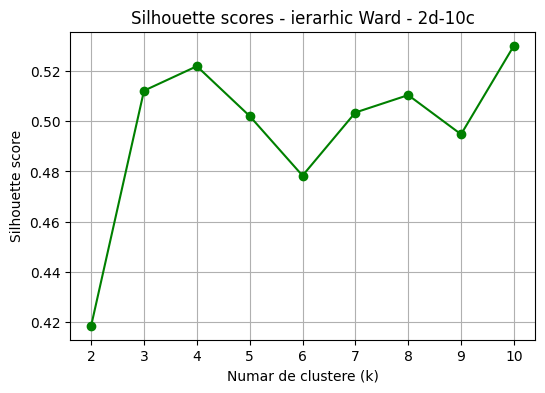

In [23]:
# valori numerice si plot silhouette - ierarhic Ward

for name, results in task2_hier_results.items():
    print(f"\n{name.upper()} - Silhouette (Ward ierarhic)")
    print("k | silhouette")
    for k, sil in zip(results["k_values"], results["silhouette_scores"]):
        print(f"{k} | {sil:.4f}")

    plt.figure(figsize=(6, 4))
    plt.plot(results["k_values"], results["silhouette_scores"], marker="o", color="green")
    plt.title(f"Silhouette scores - ierarhic Ward - {name}")
    plt.xlabel("Numar de clustere (k)")
    plt.ylabel("Silhouette score")
    plt.grid(True)
    plt.show()

### Interpretare Task 2 - comparatie K-Means vs Ierarhic Ward

#### Iris
- **K-Means elbow**: k=3 (curbura clara)
- **K-Means silhouette**: k=2 (maxim la 0.68)
- **Ierarhic elbow**: k=2 (cel mai mare salt de distanta)
- **Ierarhic silhouette**: k=2 (maxim la 0.58)
- **Concluzie**: Metodele nesupervizate sugereaza k=2 (Iris setosa bine separata, versicolor/virginica se suprapun). Cunoasterea domeniului (3 specii) sustine **k=3**. Elbow K-Means confirma aceasta alegere.

#### 2d-10c
- **K-Means elbow**: k=10 (descrestere incetinita)
- **K-Means silhouette**: k=10 (maxim la 0.55)
- **Ierarhic elbow**: k=3 (subestimat - Ward tinde sa formeze clustere mari)
- **Ierarhic silhouette**: k=10 (maxim la 0.53)
- **Concluzie**: Silhouette este mai fiabil decat elbow pentru aceasta structura cu 10 clustere. Ambii algoritmi confirma **k=10** prin silhouette, in timp ce elbow-ul ierarhic subestimeaza.

| Dataset | KMeans elbow | KMeans sil | Ierarhic elbow | Ierarhic sil | **k ales** |
|---------|-------------|-----------|----------------|-------------|------------|
| iris    | k=3         | k=2       | k=2            | k=2         | **k=3** (domeniu) |
| 2d-10c  | k=10        | k=10      | k=3            | k=10        | **k=10** |